In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
print("set up done")

set up done


In [2]:
import os
os.chdir("/home/khoiho/python_practice/luad_project")   # chdir = change directory
print("Giờ đang ở:", os.getcwd())
print(os.listdir())

Giờ đang ở: /home/khoiho/python_practice/luad_project
['volcano_luad.png', 'figures', 'results', 'GPL96-57554.txt', 'GSE10072_series_matrix.txt.gz']


In [3]:
expr = pd.read_csv(
    "GSE10072_series_matrix.txt.gz",
    sep="\t", comment="!", index_col=0)
print(expr.shape)
expr.head()

(22283, 107)


,GSM254625,GSM254626,GSM254627,GSM254628,GSM254629,GSM254630,GSM254631,GSM254632,GSM254633,GSM254634,...,GSM254722,GSM254723,GSM254724,GSM254725,GSM254726,GSM254727,GSM254728,GSM254729,GSM254730,GSM254731
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,10.927084,10.416978,10.628538,10.151180,10.988512,10.778205,10.568814,10.479425,10.548843,10.465005,...,10.727493,10.740353,10.527962,10.193615,10.768815,10.467693,10.902778,10.869402,10.292285,10.407218
1053_at,6.895217,6.924856,7.550245,6.699557,6.826031,6.718372,6.739765,6.724615,7.102475,6.627922,...,6.856575,6.737879,6.959032,7.008578,6.740444,6.795750,6.838162,6.628363,6.794050,6.358410
117_at,8.110190,7.760228,7.974676,7.712676,7.775592,7.777087,7.893210,8.058398,8.005438,7.961476,...,7.741922,7.805107,8.093078,8.144760,8.159483,7.855457,8.010428,7.889019,8.163266,7.973844
121_at,9.451286,9.520943,9.807597,9.522087,9.855061,9.861055,10.126183,9.878970,10.110318,10.411478,...,10.089149,10.007059,9.832610,10.107004,9.790645,9.645239,9.871851,9.867988,9.824801,9.850144
1255_g_at,4.814477,4.718640,4.905163,4.818076,4.823958,4.848313,5.125956,5.037979,4.889936,5.177818,...,5.048391,4.758050,4.900470,4.948760,4.609322,4.759571,4.788774,4.967626,4.817474,5.128892


In [4]:
labels_raw = None
with open ("GSE10072_series_matrix.txt.gz", "rb") as f:
    import gzip
    with gzip.open(f, "rt") as gz:
        for line in gz:
            if line.startswith("!Sample_title"):
                labels_raw = line
                break
print(labels_raw[:300])

!Sample_title	"Lung Tumor_GT00006"	"Normal Lung_GT00006"	"Lung Tumor_GT00007"	"Normal Lung_GT00007"	"Lung Tumor_GT00022"	"Lung Tumor_GT00042"	"Lung Tumor_GT00059"	"Normal Lung_GT00059"	"Lung Tumor_GT00146"	"Normal Lung_GT00146"	"Normal Lung_GT01001"	"Lung Tumor_GT01001"	"Lung Tumor_GT01003"	"Normal 


In [5]:
import re
titles = re.findall(r'"([^"]*)"', labels_raw)
print("Samples:", len(titles))
print("The first fifth samples:", titles[:5])

Samples: 107
The first fifth samples: ['Lung Tumor_GT00006', 'Normal Lung_GT00006', 'Lung Tumor_GT00007', 'Normal Lung_GT00007', 'Lung Tumor_GT00022']


In [6]:
groups = ["tumor" if "Tumor"in t else "normal" for t in titles]
from collections import Counter
print(Counter(groups))

Counter({'tumor': 58, 'normal': 49})


In [7]:
import numpy as np
groups = np.array(groups)
tumor_expr = expr.loc[:, groups == "tumor"]
normal_expr = expr.loc[:, groups == "normal"]
print("Tumor:", tumor_expr.shape)
print("Normal:", normal_expr.shape)

Tumor: (22283, 58)
Normal: (22283, 49)


In [8]:
from scipy import stats
results = pd.DataFrame(index=expr.index)
results["log2FC"] = tumor_expr.mean(axis=1) - normal_expr.mean(axis=1)
t_stats, p_values = stats.ttest_ind(tumor_expr, normal_expr, axis=1)
results["p_value"] = p_values
print(results.shape)
results.head()

(22283, 2)


,log2FC,p_value
ID_REF,,
1007_s_at,0.462727,9.008540e-12
1053_at,0.252024,4.582603e-08
117_at,0.009712,8.936803e-01
121_at,0.015309,6.452106e-01
1255_g_at,0.066207,1.149659e-02


In [9]:
from statsmodels.stats.multitest import multipletests
results["p_adj"] = multipletests(results["p_value"], method="fdr_bh")[1]
print("p < 0.05 (raw):     ", (results["p_value"] < 0.05).sum())
print("p_adj < 0.05 (FDR): ", (results["p_adj"] < 0.05).sum())
results.head()


p < 0.05 (raw):      11941
p_adj < 0.05 (FDR):  10891


,log2FC,p_value,p_adj
ID_REF,,,
1007_s_at,0.462727,9.008540e-12,1.087418e-10
1053_at,0.252024,4.582603e-08,2.909358e-07
117_at,0.009712,8.936803e-01,9.298164e-01
121_at,0.015309,6.452106e-01,7.434318e-01
1255_g_at,0.066207,1.149659e-02,2.575595e-02


In [10]:
FC_THRESHOLD = np.log2(1.5)
sig = results[(results["p_adj"] < 0.001) & (results["log2FC"].abs() > FC_THRESHOLD)]
print(f"Log2FC Threshold: {FC_THRESHOLD:.3f}")
print(f"Differentiated Probe: {len(sig)}")
print(f"Increase in Tumor: {(sig['log2FC'] > 0).sum()}")
print(f"Decrease in Tumor: {(sig['log2FC'] < 0).sum()}")
sig.reindex(sig["log2FC"].abs().sort_values(ascending=False).index).head(10)

Log2FC Threshold: 0.585
Differentiated Probe: 2313
Increase in Tumor: 996
Decrease in Tumor: 1317


,log2FC,p_value,p_adj
ID_REF,,,
210081_at,-4.417470,1.150034e-39,2.847356e-36
209875_s_at,4.364415,8.066388e-39,1.198289e-35
214387_x_at,-4.047179,5.478615e-25,4.768749e-23
211735_x_at,-4.002035,1.152250e-24,9.302748e-23
205982_x_at,-3.995120,2.882489e-25,2.721632e-23
215454_x_at,-3.989822,4.127755e-35,1.916224e-32
203980_at,-3.838541,1.963864e-37,1.683107e-34
210096_at,-3.709796,4.493787e-25,4.021489e-23
204712_at,-3.686710,6.041175e-25,5.217655e-23


In [11]:
results["neg_log_padj"] = -np.log10(results["p_adj"])
results["status"] = np.where(
    (results["p_adj"] < 0.001) & (results["log2FC"] > FC_THRESHOLD), "Up",
    np.where(
        (results["p_adj"] < 0.001) & (results["log2FC"] < -FC_THRESHOLD), "Down", "NS"))
print(results["status"].value_counts())
print("The highest value of Y:", results["neg_log_padj"].max())

status
NS      19970
Down     1317
Up        996
Name: count, dtype: int64
The highest value of Y: 38.83483457449582


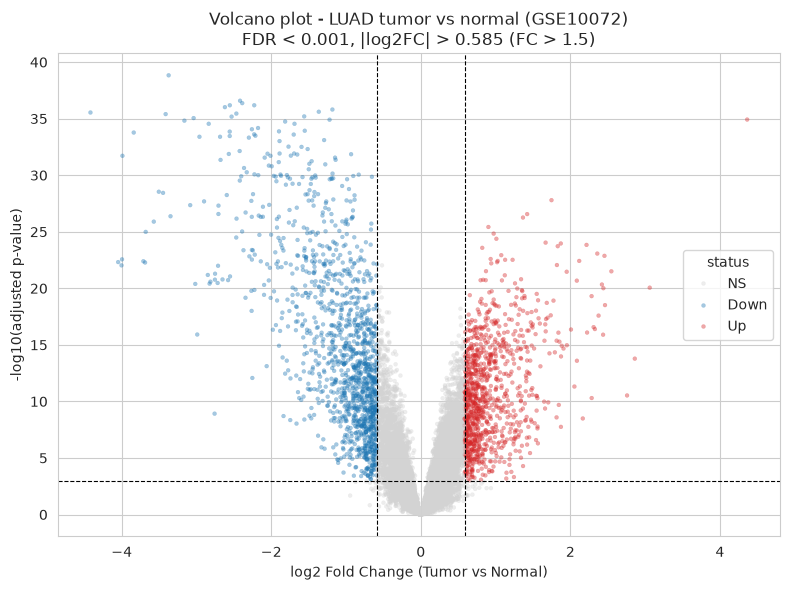

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=results, x="log2FC", y="neg_log_padj", hue="status",
    palette={"Up": "#d62728", "Down": "#1f77b4", "NS": "lightgrey"},
    s=8, alpha=0.4, edgecolor=None, ax=ax)
ax.axhline(-np.log10(0.001), ls="--", color="black", lw=0.8)
ax.axvline(FC_THRESHOLD, ls="--", color="black", lw=0.8)
ax.axvline(-FC_THRESHOLD, ls="--", color="black", lw=0.8)

ax.set_xlabel("log2 Fold Change (Tumor vs Normal)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("Volcano plot - LUAD tumor vs normal (GSE10072)\n"
            "FDR < 0.001, |log2FC| > 0.585 (FC > 1.5)")
plt.tight_layout()
plt.show()

In [13]:
fig.savefig("volcano_luad.png", dpi=300, bbox_inches="tight")

In [14]:
!cp /mnt/c/Users/*/Downloads/GPL96* ~/python_practice/luad_project/
!cd ~/python_practice/luad_project && ls -lh

total 100M
-rwxr-xr-x 1 khoiho khoiho  44M Jul 28 12:04 'GPL96-57554 (1).txt'
-rwxr-xr-x 1 khoiho khoiho  44M Jul 28 12:04  GPL96-57554.txt
-rwxr-xr-x 1 khoiho khoiho  13M Jul 22 10:32  GSE10072_series_matrix.txt.gz
drwxr-xr-x 2 khoiho khoiho 4.0K Jul 27 08:16  figures
drwxr-xr-x 2 khoiho khoiho 4.0K Jul 27 08:18  results
-rw-r--r-- 1 khoiho khoiho 608K Jul 28 12:04  volcano_luad.png


In [15]:
!rm ~/python_practice/luad_project/'GPL96-57554 (1).txt'
print("done rm")

done rm


In [16]:
!head -5 ~/python_practice/luad_project/GPL96-57554.txt!head -5 ~/python_practice/luad_project/GPL96-57554.txt

head: invalid trailing option -- 5
Try 'head --help' for more information.


In [17]:
!head -1 ~/python_practice/luad_project/GPL96-57554.txt

#ID = Affymetrix Probe Set ID


In [18]:
with open("/home/khoiho/python_practice/luad_project/GPL96-57554.txt") as f:
    header = f.readline().strip().split("\t")
print("The columns:", len(header))
for i, col in enumerate(header):
    print(i, "|", col)

The columns: 1
0 | #ID = Affymetrix Probe Set ID


In [19]:
!head -25 ~/python_practice/luad_project/GPL96-57554.txt

#ID = Affymetrix Probe Set ID
#GB_ACC = GenBank Accession Number
#SPOT_ID = identifies controls
#Species Scientific Name = The genus and species of the organism represented by the probe set.
#Annotation Date = The date that the annotations for this probe array were last updated. It will generally be earlier than the date when the annotations were posted on the Affymetrix web site.
#Sequence Type = 
#Sequence Source = The database from which the sequence used to design this probe set was taken.
#Target Description = 
#Representative Public ID = The accession number of a representative sequence. Note that for consensus-based probe sets, the representative sequence is only one of several sequences (sequence sub-clusters) used to build the consensus sequence and it is not directly used to derive the probe sequences. The representative sequence is chosen during array design as a sequence that is best associated with the transcribed region being interrogated by the probe set. Refer to the "S

In [20]:
import pandas as pd
annot = pd.read_csv("/home/khoiho/python_practice/luad_project/GPL96-57554.txt",
                    sep="\t",
                    comment="#",
                    low_memory=False)
print("Shape:", annot.shape)
print("\nColumns:")
for i, col in enumerate(annot.columns):
    print(i, "|", col)

Shape: (22283, 16)

Columns:
0 | ID
1 | GB_ACC
2 | SPOT_ID
3 | Species Scientific Name
4 | Annotation Date
5 | Sequence Type
6 | Sequence Source
7 | Target Description
8 | Representative Public ID
9 | Gene Title
10 | Gene Symbol
11 | ENTREZ_GENE_ID
12 | RefSeq Transcript ID
13 | Gene Ontology Biological Process
14 | Gene Ontology Cellular Component
15 | Gene Ontology Molecular Function


In [21]:
annot_small = annot[["ID", "Gene Symbol"]].copy()
annot_small.columns = ["probe", "gene"]
print("Before Filter:", annot_small.shape)
print("Probe without gene (NaN):", annot_small["gene"].isna().sum())
annot_small.head()

Before Filter: (22283, 2)
Probe without gene (NaN): 1058


,probe,gene
0,1007_s_at,DDR1 /// MIR4640
1,1053_at,RFC2
2,117_at,HSPA6
3,121_at,PAX8
4,1255_g_at,GUCA1A


In [22]:
res = results.reset_index()
res.columns = ["probe"] + list(res.columns[1:])
merged = pd.merge(res, annot_small, on="probe", how="left")
print("After merge:", merged.shape)
print("Probe without gene:", merged["gene"].isna().sum())
merged.head()

After merge: (22283, 7)
Probe without gene: 1058


,probe,log2FC,p_value,p_adj,neg_log_padj,status,gene
0,1007_s_at,0.462727,9.008540e-12,1.087418e-10,9.963604,NS,DDR1 /// MIR4640
1,1053_at,0.252024,4.582603e-08,2.909358e-07,6.536203,NS,RFC2
2,117_at,0.009712,8.936803e-01,9.298164e-01,0.031603,NS,HSPA6
3,121_at,0.015309,6.452106e-01,7.434318e-01,0.128759,NS,PAX8
4,1255_g_at,0.066207,1.149659e-02,2.575595e-02,1.589122,NS,GUCA1A


In [23]:
sig_named = merged[
    (merged["p_adj"] < 0.001) & (merged["log2FC"].abs() > FC_THRESHOLD)
    ].copy()
sig_named["fold_change"] = 2 ** sig_named["log2FC"]
print("=== TOP 15 DECREASE IN TUMOR ===")
print(sig_named.nsmallest(15, "log2FC")[["probe", "gene", "log2FC", "fold_change", "p_adj"]])
print("\n=== TOP 15 INCREASE IN TUMOR ===")
print(sig_named.nlargest(15, "log2FC")[["probe", "gene", "log2FC", "fold_change", "p_adj"]])

=== TOP 15 DECREASE IN TUMOR ===
             probe               gene    log2FC  fold_change         p_adj
9564     210081_at               AGER -4.417470     0.046796  2.847356e-36
13765  214387_x_at              SFTPC -4.047179     0.060489  4.768749e-23
11134  211735_x_at              SFTPC -4.002035     0.062412  9.302748e-23
5508   205982_x_at              SFTPC -3.995120     0.062712  2.721632e-23
14826  215454_x_at              SFTPC -3.989822     0.062943  1.916224e-32
3506     203980_at              FABP4 -3.838541     0.069901  1.683107e-34
9579     210096_at             CYP4B1 -3.709796     0.076426  4.021489e-23
4238     204712_at               WIF1 -3.686710     0.077659  5.217655e-23
9102   209613_s_at              ADH1B -3.678467     0.078104  1.020840e-25
18593    219230_at            TMEM100 -3.570313     0.084184  1.268561e-26
5392     205866_at               FCN3 -3.503099     0.088199  2.888240e-29
13513    214135_at             CLDN18 -3.446412     0.091733  3.631

In [24]:
def has_gene(gene_str, target):
    """True if Probe map matches with Gene target."""
    if pd.isna(gene_str):
        return False
    return target in str(gene_str).split(" ///")

for g in ["NEK2", "TTK", "PRC1"]:
    mask = merged["gene"].apply(lambda x: has_gene(x ,g))
    hits = merged[mask]
    print(f"\n=== {g} ===")
    print(hits[["probe", "gene", "log2FC", "p_adj", "status"]])


=== NEK2 ===
             probe  gene    log2FC         p_adj status
4167     204641_at  NEK2  1.515365  2.083891e-15     Up
10523  211080_s_at  NEK2  0.409274  2.540537e-10     NS

=== TTK ===
          probe gene    log2FC         p_adj status
4348  204822_at  TTK  1.151624  1.061006e-11     Up

=== PRC1 ===
             probe  gene    log2FC         p_adj status
17373  218009_s_at  PRC1  1.410437  8.240263e-13     Up


In [25]:
merged_clean = merged.dropna(subset=["gene"]).copy()
multi = merged_clean["gene"].str.contains(" ///")
merged_clean = merged_clean[~multi].copy()
probe_mean = expr.mean(axis=1)
merged_clean["mean_expr"] = merged_clean["probe"].map(probe_mean)
idx = merged_clean.groupby("gene")["mean_expr"].idxmax()
gene_level = merged_clean.loc[idx].copy()
print("The remaining merged gene: ", len(gene_level))

The remaining merged gene:  12548


In [26]:
sig_genes = gene_level[
    (gene_level["p_adj"] < 0.001) & (gene_level["log2FC"].abs() > FC_THRESHOLD)]
print(f"Differentiated Gene: {len(sig_genes)}")
print(f"  Up:   {(sig_genes['log2FC'] > 0).sum()}")
print(f" Down:  {(sig_genes['log2FC'] < 0).sum()}")
print(gene_level[gene_level["gene"] == "NEK2"][["probe", "log2FC", "p_adj", "status"]])

Differentiated Gene: 1464
  Up:   625
 Down:  839
          probe    log2FC         p_adj status
4167  204641_at  1.515365  2.083891e-15     Up


In [27]:
gene_level["nef_log_padj"] = -np.log10(gene_level["p_adj"])
top_up = gene_level[gene_level["status"] == "Up"].nlargest(8, "log2FC")
top_down = gene_level[gene_level["status"] =="Down"].nsmallest(8, "log2FC")
paper_genes = gene_level[gene_level["gene"].isin(["NEK2", "TTK", "PRC1"])]
to_label = pd.concat([top_up, top_down, paper_genes]).drop_duplicates(subset="gene")
print(f"Have labelled {len(to_label)} genes.")
print(to_label[["gene", "log2FC", "p_adj"]].to_string())
    

Have labelled 19 genes.
          gene    log2FC         p_adj
9360      SPP1  4.364415  1.198289e-35
4001      MMP1  2.862036  1.649280e-14
5764    SPINK1  2.758400  2.958751e-11
17833    GREM1  2.548363  3.121647e-22
819      TOP2A  2.455963  1.340679e-23
4106     MMP12  2.377325  2.587063e-18
1837    COL1A1  2.328322  4.007069e-17
15992     TOX3  2.311316  2.699656e-17
9564      AGER -4.417470  2.847356e-36
3506     FABP4 -3.838541  1.683107e-34
9579    CYP4B1 -3.709796  4.021489e-23
4238      WIF1 -3.686710  5.217655e-23
18593  TMEM100 -3.570313  1.268561e-26
5392      FCN3 -3.503099  2.888240e-29
13513   CLDN18 -3.446412  3.631939e-29
8567   FAM107A -3.371799  1.462734e-39
4167      NEK2  1.515365  2.083891e-15
17373     PRC1  1.410437  8.240263e-13
4348       TTK  1.151624  1.061006e-11


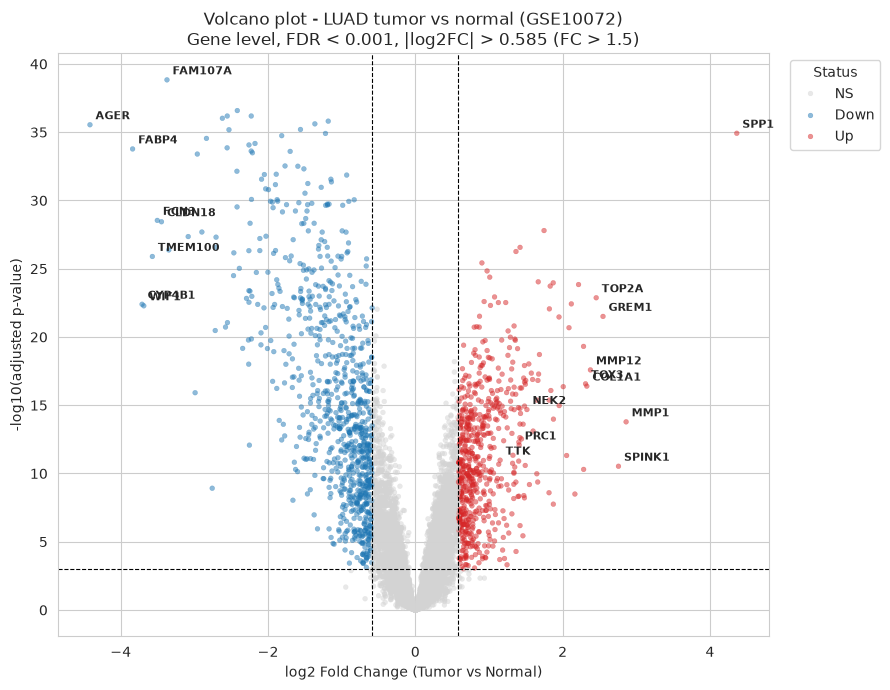

In [28]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=gene_level, x="log2FC", y="neg_log_padj", hue="status",
    palette={"Up": "#d62728", "Down": "#1f77b4", "NS": "lightgrey"},
    s=12, alpha=0.5, edgecolor=None, ax=ax)
ax.axhline(-np.log10(0.001), ls="--", color="black", lw=0.8)
ax.axvline(FC_THRESHOLD, ls="--", color="black", lw=0.8)
ax.axvline(-FC_THRESHOLD, ls="--", color="black", lw=0.8)

for _, row in to_label.iterrows():
    ax.annotate(
        row["gene"],
        xy=(row["log2FC"], row["neg_log_padj"]),
        xytext=(4, 4), textcoords="offset points",
        fontsize=8, fontweight="bold")
ax.set_xlabel("log2 Fold Change (Tumor vs Normal)")
ax.set_ylabel("-log10(adjusted p-value)")
ax.set_title("Volcano plot - LUAD tumor vs normal (GSE10072)\n"
             "Gene level, FDR < 0.001, |log2FC| > 0.585 (FC > 1.5)")
ax.legend(title="Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
    

In [29]:
import os
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
fig.savefig("figures/volcano_gene_level.png", dpi=300, bbox_inches="tight")
fig.savefig("figures/volcano_gene_level.pdf", bbox_inches="tight")

out = sig_genes.copy()
out["fold_change"] = 2 ** out["log2FC"]
out = out.reindex(out["log2FC"].abs().sort_values(ascending=False).index)
out[["gene", "probe", "log2FC", "fold_change", "p_value", "p_adj", "status"]].to_csv(
    "results/DEG_gene_level.csv", index=False)
gene_level.to_csv("results/all_genes_results.csv", index=False)
print("Saved")
print(os.listdir("figures"), os.listdir("results"))

Saved
['volcano_gene_level.png', 'volcano_gene_level.pdf'] ['all_genes_results.csv', 'DEG_gene_level.csv']


In [30]:
import os
print("Thư mục hiện tại:", os.getcwd())
print("\nfigures/:", os.listdir("figures"))
print("results/:", os.listdir("results"))

Thư mục hiện tại: /home/khoiho/python_practice/luad_project

figures/: ['volcano_gene_level.png', 'volcano_gene_level.pdf']
results/: ['all_genes_results.csv', 'DEG_gene_level.csv']


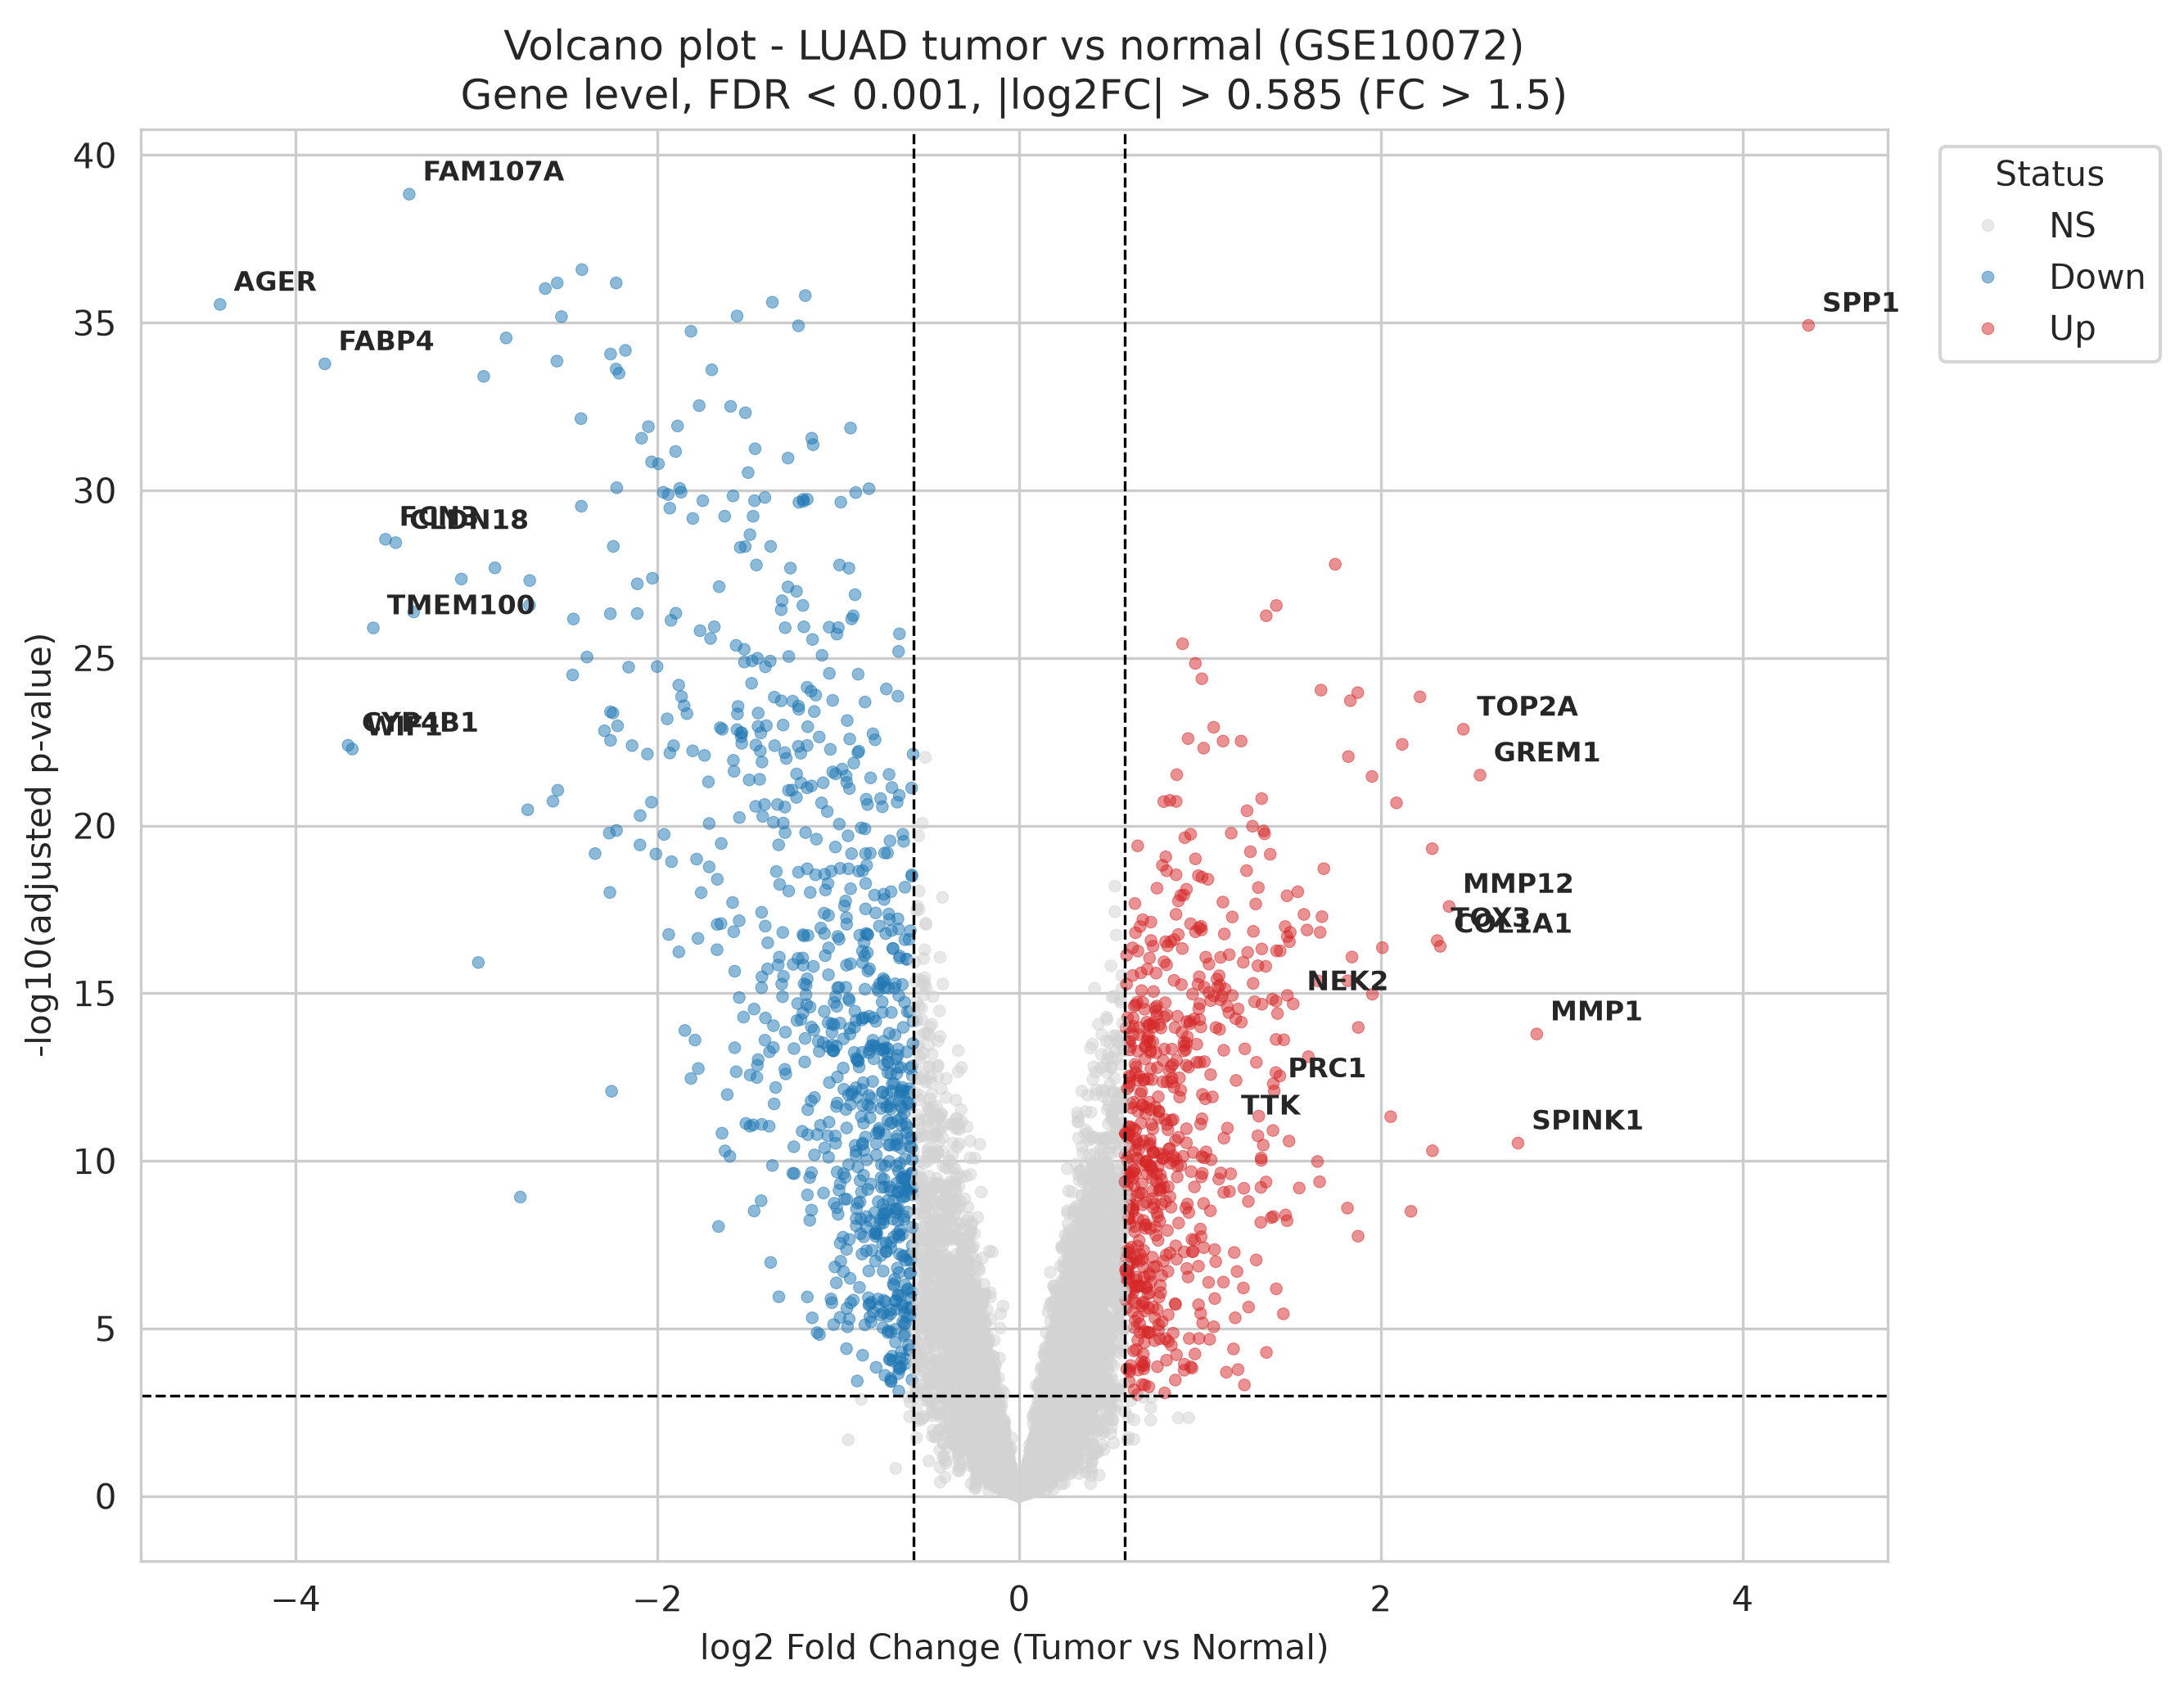

In [31]:
from IPython.display import Image
Image("figures/volcano_gene_level.png")

In [32]:
import os
print(os.listdir("/mnt/c/Users/"))

['All Users', 'Default', 'Default User', 'desktop.ini', 'Kḥôi', 'Public']


In [33]:
import glob
DOWNLOADS = [d for d in glob.glob("/mnt/c/Users/*/Downloads")
             if "Default" not in d and "Public" not in d][0]
print("Downloads:", DOWNLOADS)

# Từ giờ chỉ cần:
# os.system(f'cp file.png "{DOWNLOADS}/"')

Downloads: /mnt/c/Users/Kḥôi/Downloads
